<a href="https://colab.research.google.com/github/sxiayuan/ideogram4-optimization/blob/main/MagicHourOptimize2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%cd /content

!rm -rf /content/ideogram4
!git clone https://github.com/ideogram-oss/ideogram4.git

%cd /content/ideogram4

!pip install -q bitsandbytes

/content
Cloning into 'ideogram4'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 71 (delta 12), reused 10 (delta 10), pack-reused 49 (from 1)
Receiving objects: 100% (71/71), 10.19 MiB | 56.70 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/ideogram4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.3 MB/s eta 0:00:00


In [ ]:
import os

from getpass import getpass
from huggingface_hub import login, whoami

hf_token = getpass(
    "Paste your Hugging Face token. It should start with hf_: "
)

login(
    token=hf_token,
    add_to_git_credential=True
)

os.environ["HF_TOKEN"] = hf_token
os.environ["HUGGING_FACE_HUB_TOKEN"] = hf_token

user = whoami(token=hf_token)

print("Logged in as:", user["name"])

Paste your Hugging Face token. It should start with hf_: ··········


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in as: sxiayuan


In [ ]:
import sys
import importlib
from pathlib import Path
import torch

# =====================================
# Clean cached Ideogram imports
# =====================================

for module_name in list(sys.modules.keys()):
    if module_name.startswith("ideogram4"):
        del sys.modules[module_name]

IDEOGRAM_SRC = "/content/ideogram4/src"

# Remove duplicate path if exists
sys.path = [
    path for path in sys.path
    if path != IDEOGRAM_SRC
]

# Add Ideogram source
sys.path.insert(0, IDEOGRAM_SRC)

importlib.invalidate_caches()


# =====================================
# Verify package
# =====================================

print("sys.path[0]:", sys.path[0])
print(
    "Package folder:",
    Path("/content/ideogram4/src/ideogram4").exists()
)

import ideogram4

print("SUCCESS:", ideogram4)
print("Loaded from:", ideogram4.__file__)


# =====================================
# Import pipeline classes
# =====================================

from ideogram4 import (
    Ideogram4Pipeline,
    Ideogram4PipelineConfig
)

print("Ideogram pipeline classes imported.")


# =====================================
# Load Ideogram 4 FP8 model
# =====================================

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


pipe = Ideogram4Pipeline.from_pretrained(
    config=Ideogram4PipelineConfig(
        weights_repo="ideogram-ai/ideogram-4-fp8"
    ),
    device=device,
    dtype=torch.bfloat16
)


# =====================================
# Inference optimizations
# =====================================

torch.set_float32_matmul_precision("high")

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


print("Ideogram FP8 loaded.")
print("Pipeline ready:", type(pipe))

sys.path[0]: /content/ideogram4/src
Package folder: True
SUCCESS: <module 'ideogram4' from '/content/ideogram4/src/ideogram4/__init__.py'>
Loaded from: /content/ideogram4/src/ideogram4/__init__.py
Ideogram pipeline classes imported.
Device: cuda


(…)ion_pytorch_model.safetensors.index.json:   0%|          | 0.00/50.4k [00:00<?, ?B/s]

transformer/diffusion_pytorch_model.safe(…): reconstructing file:   0%|          |  0.00B / 9.29GB            

transformer/diffusion_pytorch_model.safe(…): downloading bytes:           |  0.00B            

unconditional_transformer/diffusion_pyto(…): reconstructing file:   0%|          |  0.00B / 9.29GB            

...

config.json:   0%|          | 0.00/1.57k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/76.1k [00:00<?, ?B/s]

text_encoder/model.safetensors: reconstructing file:   0%|          |  0.00B / 8.78GB            

text_encoder/model.safetensors: downloading bytes:           |  0.00B            

Ideogram FP8 loaded.
Pipeline ready: <class 'ideogram4.pipeline_ideogram4.Ideogram4Pipeline'>


Using default Ideogram prompt:
{"high_level_description":"A dramatic and intense scene of Godzilla attacking Tokyo, capturing the chaos and destruction with a cinematic and immersive perspective. The iconic monster dominates the frame, its massive form casting long shadows across the devastated cityscape. The urban environment is filled with debris and damaged buildings, emphasizing the scale of the devastation. The sky is filled with smoke and dust, adding to the apocalyptic atmosphere. The camera follows Godzilla's movement
Generating with seed: 1782955390
Generation time: 11.25s


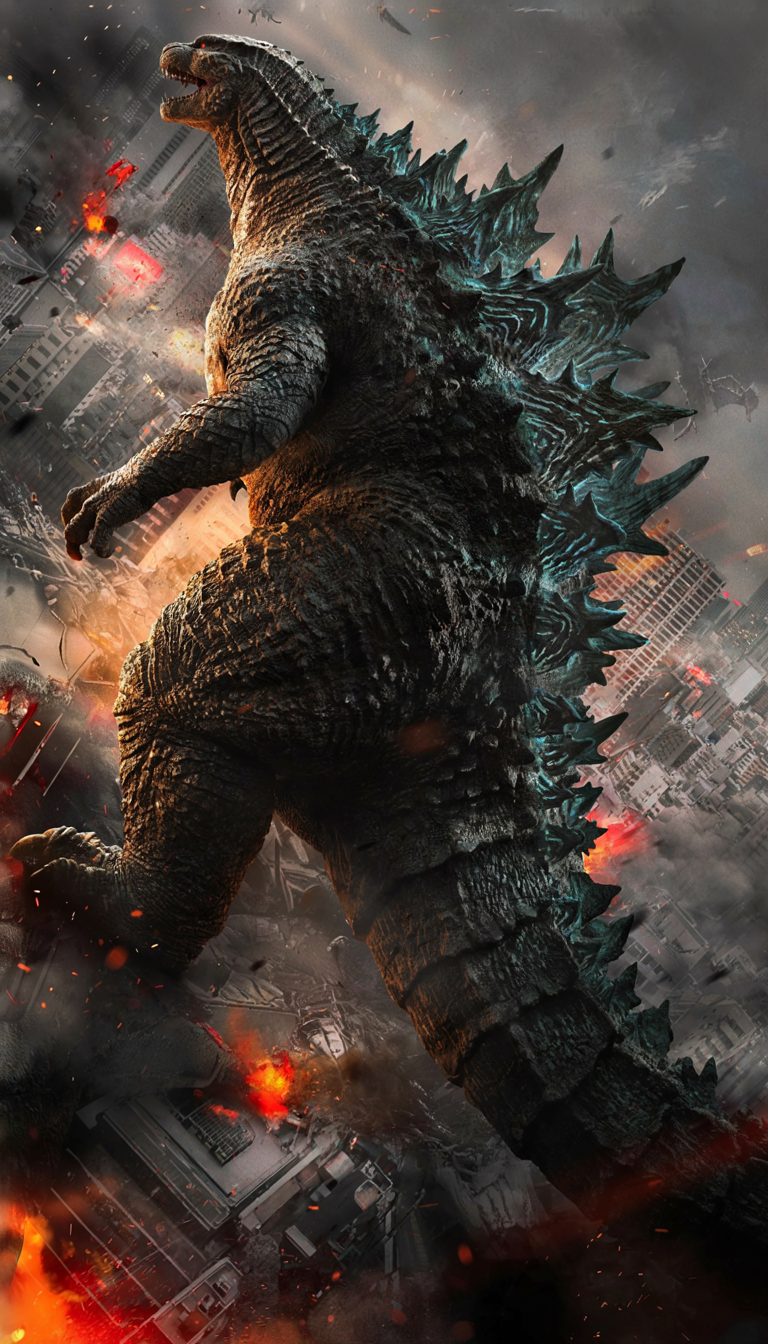

In [ ]:
import json
import time
import torch

# ==============================
# DEFAULT IDEOGRAM PROMPT
# ==============================

DEFAULT_PROMPT = {
  "high_level_description": "A dramatic and intense scene of Godzilla attacking Tokyo, capturing the chaos and destruction with a cinematic and immersive perspective. The iconic monster dominates the frame, its massive form casting long shadows across the devastated cityscape. The urban environment is filled with debris and damaged buildings, emphasizing the scale of the devastation. The sky is filled with smoke and dust, adding to the apocalyptic atmosphere. The camera follows Godzilla's movements, providing a dynamic and thrilling experience. The color palette features deep, muted tones of gray and brown, punctuated by the bright red of the monster's eyes and the fiery orange of explosions. The overall composition is designed to evoke a sense of awe and terror, immersing the viewer in the heart of the battle.",

  "style_description": {
    "aesthetics": "A cinematic and immersive visual style, featuring dramatic lighting, detailed textures, and a high level of realism. The scene is rendered with a focus on creating a sense of scale and intensity, utilizing a combination of photorealistic and stylized elements to enhance the impact.",

    "lighting": "The lighting is designed to create a dramatic and intense atmosphere, with high contrast between the dark, smoky sky and the bright, fiery explosions. The light sources are strategically placed to highlight the destruction and the imposing presence of Godzilla, with deep shadows and sharp highlights adding to the sense of depth and realism.",

    "photo": "The framing is dynamic, following Godzilla's movements to capture the full scope of the attack. The camera angle is low, emphasizing the monster's dominance and the scale of the destruction. The perspective is wide, allowing for a comprehensive view of the urban landscape and the chaos unfolding. The focus is on the main subject, with a shallow depth of field blurring the background slightly to draw attention to Godzilla. The composition is designed to create a sense of immersion, making the viewer feel as though they are part of the scene.",

    "medium": "photograph",

    "color_palette": [
      "#4A4A4A",
      "#D2691E",
      "#FF4500",
      "#8B0000",
      "#F4A460"
    ]
  },

  "compositional_deconstruction": {
    "background": "The background features a devastated urban landscape, with damaged buildings, debris, and smoke filling the sky. The color palette is dominated by muted tones of gray and brown, with occasional bright reds and oranges from explosions and fires. The negative space is used to emphasize the scale of the destruction and the imposing presence of Godzilla.",

    "elements": [
      {
        "type": "obj",
        "bbox": [
          100,
          50,
          900,
          950
        ],

        "desc": "Godzilla, the iconic monster, is depicted in a powerful and aggressive stance, its massive form dominating the frame. The creature's scales are detailed, with a mix of rough, textured surfaces and smooth, glossy areas reflecting the chaotic environment. The lighting highlights the creature's imposing presence, with deep shadows and sharp highlights accentuating its form. The color palette features deep greens and browns, with bright red accents from the monster's eyes and the fiery explosions around it. The camera follows Godzilla's movements, providing a dynamic and thrilling experience.",

        "color_palette": [
          "#4A4A4A",
          "#D2691E",
          "#FF4500",
          "#8B0000",
          "#F4A460"
        ]
      }
    ]
  }
}


# Convert JSON object to Ideogram input string
ideogram_prompt = json.dumps(
    DEFAULT_PROMPT,
    ensure_ascii=False,
    separators=(",", ":")
)


print("Using default Ideogram prompt:")
print(ideogram_prompt[:500])


# ==============================
# GENERATION
# ==============================

SEED = 1782955390

print("Generating with seed:", SEED)


start_time = time.perf_counter()

with torch.inference_mode():

    result = pipe(
        ideogram_prompt,
        width=768,
        height=1344,
        num_steps=12,
        guidance_schedule=(4.0,) + (8.0,) * 11,
        mu=0.55,
        std=1.75,
        seed=SEED
    )


generation_time = time.perf_counter() - start_time

print(f"Generation time: {generation_time:.2f}s")
image = result[0]
image

In [ ]:
from PIL import Image
from IPython.display import display

SEED = 532938188

path = (
    Path("/content/ideogram_outputs/draft_generations")
    / f"draft_seed_{SEED}_768x1024.png"
)

display(Image.open(path))